# A/B Test Design and Evaluation

**Domain:** Product Analytics  
**Dataset:** Udacity A/B Testing Final Project Dataset (public)  
**Language:** Python

---

## Business Problem

A/B testing is the primary tool for evidence-based product decisions. Whether evaluating a new onboarding flow, a pricing change, or a UI redesign, a well-designed and correctly analysed experiment separates a data-driven decision from a guess. Poorly designed or analysed experiments are pervasive — underpowered tests, multiple testing without correction, peeking at results early, and ignoring heterogeneous treatment effects are common failure modes that a skilled analyst must identify and avoid.

This project implements a complete A/B test analysis workflow using data from a real Udacity experiment: pre-experiment power analysis, randomisation sanity checks, primary metric evaluation using both frequentist and Bayesian approaches, subgroup analysis, sequential testing, and novelty effect detection.

**Central question:** Did the screener question meaningfully reduce early course cancellations, and are we confident enough in the result to launch the change to all users?

---

**Notebook structure:**
1. Setup and data loading
2. Experiment design review
3. Sanity checks
4. Primary metric analysis — frequentist
5. Primary metric analysis — Bayesian
6. Sequential testing and the peeking problem
7. Subgroup analysis
8. Novelty effect assessment
9. Results summary and launch recommendation

---
*industry_projects - Samantha McGarrigle*

## 1. Setup and Data Loading

### Data
The data comes from Udacity's A/B Testing course (ud257). Download the two CSV files
and place them in a `data/` subfolder:

- **Control:** https://raw.githubusercontent.com/baumanab/udacity_ABTesting/master/data/Final%20Project%20Results%20-%20Control.csv
- **Experiment:** https://raw.githubusercontent.com/baumanab/udacity_ABTesting/master/data/Final%20Project%20Results%20-%20Experiment.csv

Save them as `data/control_data.csv` and `data/experiment_data.csv`.

The CSVs are downloaded within the setup code below.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import beta as beta_dist
import statsmodels.stats.proportion as smp
import statsmodels.stats.power as smpow
import urllib.request
import os
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', font_scale=1.1)
BLUE  = '#2C7BB6'
RED   = '#D7191C'
GREY  = '#636363'

# Download data if not already present
os.makedirs('data', exist_ok=True)

files = {
    'data/control_data.csv': (
        'https://raw.githubusercontent.com/baumanab/udacity_ABTesting/'
        'master/data/Final%20Project%20Results%20-%20Control.csv'
    ),
    'data/experiment_data.csv': (
        'https://raw.githubusercontent.com/baumanab/udacity_ABTesting/'
        'master/data/Final%20Project%20Results%20-%20Experiment.csv'
    )
}

for path, url in files.items():
    if not os.path.exists(path):
        print(f'Downloading {path}...')
        urllib.request.urlretrieve(url, path)
        print(f'  Saved to {path}')
    else:
        print(f'  {path} already exists, skipping download')

# Load raw data
control    = pd.read_csv('data/control_data.csv')
experiment = pd.read_csv('data/experiment_data.csv')

print('\nControl shape:   ', control.shape)
print('Experiment shape:', experiment.shape)
print('\nControl columns:', list(control.columns))
control.head()

  Saved to data/control_data.csv
  Saved to data/experiment_data.csv

Control shape:    (37, 5)
Experiment shape: (37, 5)

Control columns: ['Date', 'Pageviews', 'Clicks', 'Enrollments', 'Payments']


,Date,Pageviews,Clicks,Enrollments,Payments
0,"Sat, Oct 11",7723,687,134.0,70.0
1,"Sun, Oct 12",9102,779,147.0,70.0
2,"Mon, Oct 13",10511,909,167.0,95.0
3,"Tue, Oct 14",9871,836,156.0,105.0
4,"Wed, Oct 15",10014,837,163.0,64.0


In [5]:
# Standardise column names and add group labels
control.columns    = [c.strip() for c in control.columns]
experiment.columns = [c.strip() for c in experiment.columns]

control['group']    = 'control'
experiment['group'] = 'treatment'

df = pd.concat([control, experiment], ignore_index=True)

# Dates in the dataset have no year — experiment ran in 2014
df['Date'] = pd.to_datetime(df['Date'] + ', 2014', format='%a, %b %d, %Y')
df['dow']  = df['Date'].dt.day_name()

print('Combined dataset shape:', df.shape)
print('Date range:', df['Date'].min().date(), '–', df['Date'].max().date())
print('\nMissing values:')
print(df.isnull().sum())
df.head()

Combined dataset shape: (74, 7)
Date range: 2014-10-11 – 2014-11-16

Missing values:
Date            0
Pageviews       0
Clicks          0
Enrollments    28
Payments       28
group           0
dow             0
dtype: int64


,Date,Pageviews,Clicks,Enrollments,Payments,group,dow
0,2014-10-11,7723,687,134.0,70.0,control,Saturday
1,2014-10-12,9102,779,147.0,70.0,control,Sunday
2,2014-10-13,10511,909,167.0,95.0,control,Monday
3,2014-10-14,9871,836,156.0,105.0,control,Tuesday
4,2014-10-15,10014,837,163.0,64.0,control,Wednesday


## 2. Experiment Design Review

Before analysing results, it is essential to document the experimental design and compute the required sample size prospectively. Running a power analysis after the fact — or adjusting the design based on observed results — invalidates the statistical guarantees of the test.

### Experimental setup

| Element | Value |
|---------|-------|
| Unit of randomisation | Cookie (website visit) |
| Control | Standard enrollment page |
| Treatment | Enrollment page with time commitment screener |
| Invariant metric | Number of cookies (sanity check) |
| Primary metric | Net conversion = payments / unique cookies |
| Secondary metric | Gross conversion = enrollments / unique cookies |
| Hypothesis | Screener reduces early cancellations (↓ gross conversion) without reducing payments (net conversion) |

### Metric definitions
- **Gross conversion:** proportion of unique cookies who clicked the enrollment button that actually enrolled in the free trial. Measures top-of-funnel impact.
- **Net conversion:** proportion of unique cookies who clicked the enrollment button that remained enrolled past the 14-day trial and made a payment. Measures bottom-of-funnel impact — the business metric that matters most.

In [6]:
# ── Power analysis ────────────────────────────────────────────────────────────
# Baseline conversion rates (from Udacity's pre-experiment estimates)
baseline_gross = 0.2063   # gross conversion: ~20.6% of clicks enroll
baseline_net   = 0.1093   # net conversion:   ~10.9% of clicks pay

# Minimum detectable effect (practical significance threshold)
mde_gross = 0.01   # 1 percentage point change in gross conversion
mde_net   = 0.0075 # 0.75 percentage point change in net conversion

alpha = 0.05
power = 0.80

def required_sample_size(baseline, mde, alpha=0.05, power=0.80):
    """Two-proportion z-test sample size per group."""
    effect_size = smp.proportion_effectsize(baseline, baseline + mde)
    n = smpow.zt_ind_solve_power(
        effect_size = effect_size,
        alpha       = alpha,
        power       = power,
        alternative = 'two-sided'
    )
    return int(np.ceil(n))

n_gross = required_sample_size(baseline_gross, mde_gross)
n_net   = required_sample_size(baseline_net,   mde_net)

print(f'Required sample size per group:')
print(f'  Gross conversion (MDE = {mde_gross:.1%}): {n_gross:,}')
print(f'  Net conversion   (MDE = {mde_net:.2%}): {n_net:,}')
print(f'  Binding constraint: {max(n_gross, n_net):,} per group')
print(f'  Total required: {max(n_gross, n_net)*2:,}')

Required sample size per group:
  Gross conversion (MDE = 1.0%): 26,158
  Net conversion   (MDE = 0.75%): 27,976
  Binding constraint: 27,976 per group
  Total required: 55,952


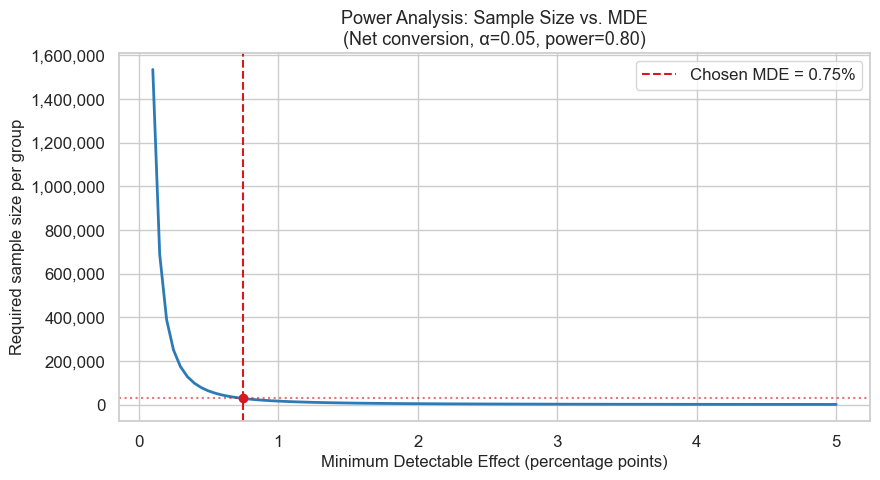

In [7]:
# Sample size curve: how n changes with MDE
mde_range = np.linspace(0.001, 0.05, 100)
n_curve   = [required_sample_size(baseline_net, m) for m in mde_range]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(mde_range * 100, n_curve, color=BLUE, linewidth=2)
ax.axvline(mde_net * 100, color=RED, linestyle='--', label=f'Chosen MDE = {mde_net:.2%}')
ax.axhline(n_net, color=RED, linestyle=':', alpha=0.6)
ax.scatter([mde_net * 100], [n_net], color=RED, zorder=5)
ax.set_xlabel('Minimum Detectable Effect (percentage points)', fontsize=12)
ax.set_ylabel('Required sample size per group', fontsize=12)
ax.set_title('Power Analysis: Sample Size vs. MDE\n(Net conversion, α=0.05, power=0.80)', fontsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
plt.tight_layout()
plt.show()

## 3. Sanity Checks

Before evaluating primary metrics, we verify that randomisation worked correctly. If invariant metrics — quantities that should not change due to the treatment — differ between groups, the experiment is compromised and results cannot be trusted.

**Invariant metric:** Number of cookies (pageviews). The screener is shown after a cookie clicks the enrollment button, so cookie counts before that action should be balanced 50/50 between groups.

In [8]:
# ── Randomisation balance check ───────────────────────────────────────────────
ctrl = df[df['group'] == 'control']
trt  = df[df['group'] == 'treatment']

n_ctrl = ctrl['Pageviews'].sum()
n_trt  = trt['Pageviews'].sum()
n_total = n_ctrl + n_trt

print('=== Cookie (pageview) balance ===')
print(f'  Control:   {n_ctrl:,}  ({n_ctrl/n_total:.1%})')
print(f'  Treatment: {n_trt:,}  ({n_trt/n_total:.1%})')
print(f'  Total:     {n_total:,}')

# Chi-square test for balance
observed  = np.array([n_ctrl, n_trt])
expected  = np.array([n_total / 2, n_total / 2])
chi2, p   = stats.chisquare(observed, expected)

print(f'\nChi-square test: χ²={chi2:.4f},  p={p:.4f}')
print('Sanity check:', 'PASS ✓' if p > 0.05 else 'FAIL ✗')

=== Cookie (pageview) balance ===
  Control:   345,543  (50.1%)
  Treatment: 344,660  (49.9%)
  Total:     690,203

Chi-square test: χ²=1.1297,  p=0.2878
Sanity check: PASS ✓


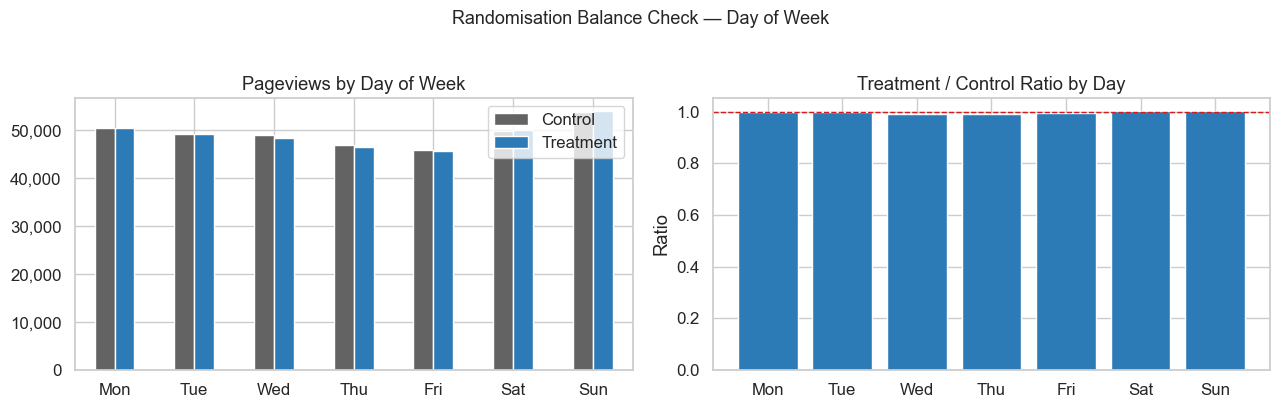


Treatment/Control ratio by day (should be ~1.0):
dow
Monday       0.997
Tuesday      1.000
Wednesday    0.989
Thursday     0.991
Friday       0.996
Saturday     1.004
Sunday       1.004


In [9]:
# ── Day-of-week trend check ───────────────────────────────────────────────────
# Verify no systematic day-of-week imbalance between groups
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

dow_balance = df.groupby(['dow', 'group'])['Pageviews'].sum().unstack()
dow_balance = dow_balance.reindex(dow_order)
dow_balance['ratio'] = dow_balance['treatment'] / dow_balance['control']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

dow_balance[['control','treatment']].plot(kind='bar', ax=axes[0],
    color=[GREY, BLUE], edgecolor='white')
axes[0].set_title('Pageviews by Day of Week')
axes[0].set_xlabel('')
axes[0].set_xticklabels([d[:3] for d in dow_order], rotation=0)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].legend(['Control', 'Treatment'])

axes[1].bar(range(7), dow_balance['ratio'], color=BLUE, edgecolor='white')
axes[1].axhline(1.0, color=RED, linestyle='--', linewidth=1)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels([d[:3] for d in dow_order])
axes[1].set_title('Treatment / Control Ratio by Day')
axes[1].set_ylabel('Ratio')

plt.suptitle('Randomisation Balance Check — Day of Week', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('\nTreatment/Control ratio by day (should be ~1.0):')
print(dow_balance['ratio'].round(3).to_string())

## 4. Primary Metric Analysis — Frequentist

We evaluate both metrics using two-proportion z-tests. Statistical significance alone is not sufficient — we also assess **practical significance**: whether the estimated effect exceeds the minimum detectable effect (MDE) threshold that was set prospectively based on business impact.

**Bonferroni correction** is applied to adjust the significance threshold for testing two metrics simultaneously: α_adjusted = 0.05 / 2 = 0.025.

In [10]:
# ── Aggregate totals for each metric ─────────────────────────────────────────
# Drop rows with missing enrollment/payment data (these are days outside
# the experiment window where payments were not yet trackable)
df_complete = df.dropna(subset=['Enrollments', 'Payments'])

ctrl_c = df_complete[df_complete['group'] == 'control']
trt_c  = df_complete[df_complete['group'] == 'treatment']

# Clicks = denominator for both conversion metrics
clicks_ctrl = ctrl_c['Clicks'].sum()
clicks_trt  = trt_c['Clicks'].sum()

enroll_ctrl = ctrl_c['Enrollments'].sum()
enroll_trt  = trt_c['Enrollments'].sum()

pay_ctrl    = ctrl_c['Payments'].sum()
pay_trt     = trt_c['Payments'].sum()

gross_ctrl  = enroll_ctrl / clicks_ctrl
gross_trt   = enroll_trt  / clicks_trt
net_ctrl    = pay_ctrl    / clicks_ctrl
net_trt     = pay_trt     / clicks_trt

print('=== Observed conversion rates ===')
print(f'  Gross conversion — Control: {gross_ctrl:.4f}  Treatment: {gross_trt:.4f}  Δ: {gross_trt - gross_ctrl:+.4f}')
print(f'  Net conversion   — Control: {net_ctrl:.4f}  Treatment: {net_trt:.4f}  Δ: {net_trt - net_ctrl:+.4f}')

=== Observed conversion rates ===
  Gross conversion — Control: 0.2189  Treatment: 0.1983  Δ: -0.0206
  Net conversion   — Control: 0.1176  Treatment: 0.1127  Δ: -0.0049


In [11]:
# ── Two-proportion z-tests with Bonferroni correction ─────────────────────────
alpha_bonf = 0.05 / 2  # two metrics

def run_ztest(successes_ctrl, n_ctrl, successes_trt, n_trt, mde, alpha=alpha_bonf):
    """Two-proportion z-test returning effect size, CI, p-value, and significance flags."""
    p_ctrl = successes_ctrl / n_ctrl
    p_trt  = successes_trt  / n_trt
    diff   = p_trt - p_ctrl

    z, p = smp.proportions_ztest(
        count    = np.array([successes_trt, successes_ctrl]),
        nobs     = np.array([n_trt, n_ctrl]),
        alternative = 'two-sided'
    )

    # 95% CI on the difference (using Bonferroni-adjusted alpha)
    se   = np.sqrt(p_ctrl*(1-p_ctrl)/n_ctrl + p_trt*(1-p_trt)/n_trt)
    z_ci = stats.norm.ppf(1 - alpha/2)
    ci   = (diff - z_ci*se, diff + z_ci*se)

    stat_sig  = p < alpha
    prac_sig  = abs(diff) >= mde

    return dict(p_ctrl=p_ctrl, p_trt=p_trt, diff=diff,
                z=z, p=p, ci=ci,
                stat_sig=stat_sig, prac_sig=prac_sig)

gross_result = run_ztest(enroll_ctrl, clicks_ctrl, enroll_trt, clicks_trt, mde_gross)
net_result   = run_ztest(pay_ctrl,    clicks_ctrl, pay_trt,    clicks_trt, mde_net)

for name, res, mde in [('Gross conversion', gross_result, mde_gross),
                        ('Net conversion',   net_result,   mde_net)]:
    print(f'\n=== {name} ===')
    print(f"  Control:  {res['p_ctrl']:.4f}")
    print(f"  Treatment:{res['p_trt']:.4f}")
    print(f"  Δ (trt − ctrl): {res['diff']:+.4f}")
    print(f"  95% CI: [{res['ci'][0]:+.4f}, {res['ci'][1]:+.4f}]")
    print(f"  z = {res['z']:.3f},  p = {res['p']:.4f}")
    print(f"  Statistically significant (α={alpha_bonf}): {'Yes' if res['stat_sig'] else 'No'}")
    print(f"  Practically significant (MDE={mde:.2%}): {'Yes' if res['prac_sig'] else 'No'}")


=== Gross conversion ===
  Control:  0.2189
  Treatment:0.1983
  Δ (trt − ctrl): -0.0206
  95% CI: [-0.0304, -0.0108]
  z = -4.702,  p = 0.0000
  Statistically significant (α=0.025): Yes
  Practically significant (MDE=1.00%): Yes

=== Net conversion ===
  Control:  0.1176
  Treatment:0.1127
  Δ (trt − ctrl): -0.0049
  95% CI: [-0.0126, +0.0028]
  z = -1.419,  p = 0.1558
  Statistically significant (α=0.025): No
  Practically significant (MDE=0.75%): No


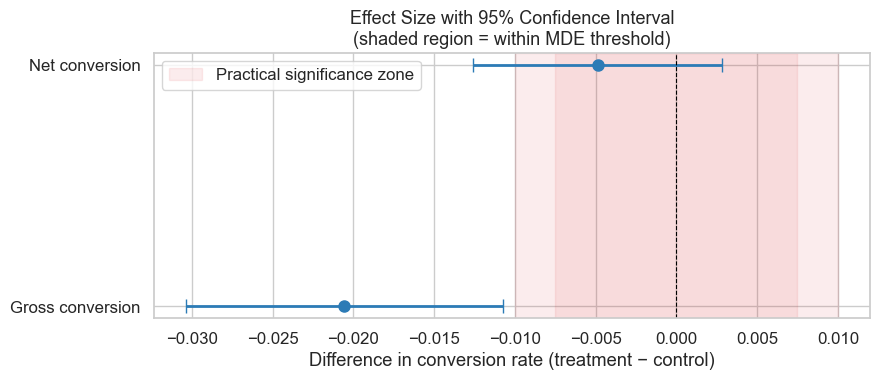

In [12]:
# Effect size plot with CI and MDE thresholds
metrics  = ['Gross conversion', 'Net conversion']
diffs    = [gross_result['diff'], net_result['diff']]
ci_low   = [gross_result['ci'][0], net_result['ci'][0]]
ci_high  = [gross_result['ci'][1], net_result['ci'][1]]
mdes     = [mde_gross, mde_net]

fig, ax = plt.subplots(figsize=(9, 4))

for i, (metric, diff, lo, hi, mde) in enumerate(zip(metrics, diffs, ci_low, ci_high, mdes)):
    ax.errorbar(diff, i, xerr=[[diff - lo], [hi - diff]],
                fmt='o', color=BLUE, capsize=5, linewidth=2, markersize=8)
    ax.axvspan(-mde, mde, alpha=0.08, color=RED,
               label='Practical significance zone' if i == 0 else '')

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(range(len(metrics)))
ax.set_yticklabels(metrics)
ax.set_xlabel('Difference in conversion rate (treatment − control)')
ax.set_title('Effect Size with 95% Confidence Interval\n(shaded region = within MDE threshold)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## 5. Primary Metric Analysis — Bayesian

The frequentist analysis tells us whether the observed difference is unlikely under the null. The Bayesian analysis answers a more directly useful question: **given the data, what is the probability that treatment is better than control?**

We model conversion rates as Beta distributions (the conjugate prior for binomial data) and use Monte Carlo sampling to estimate the full posterior distribution of the treatment effect.

In [13]:
# ── Beta-binomial Bayesian model ──────────────────────────────────────────────
# Prior: Beta(1, 1) — uninformative uniform prior
# Posterior: Beta(1 + successes, 1 + failures)

N_SAMPLES = 100_000
rng = np.random.default_rng(42)

def bayesian_comparison(successes_ctrl, n_ctrl, successes_trt, n_trt, metric_name):
    # Posterior distributions
    post_ctrl = beta_dist(
        a = 1 + successes_ctrl,
        b = 1 + (n_ctrl - successes_ctrl)
    )
    post_trt = beta_dist(
        a = 1 + successes_trt,
        b = 1 + (n_trt - successes_trt)
    )

    # Monte Carlo samples
    samples_ctrl = post_ctrl.rvs(N_SAMPLES, random_state=rng)
    samples_trt  = post_trt.rvs(N_SAMPLES,  random_state=rng)
    diff_samples = samples_trt - samples_ctrl

    p_trt_better = (diff_samples > 0).mean()
    ci_95        = np.percentile(diff_samples, [2.5, 97.5])
    ci_95_ctrl   = np.percentile(samples_ctrl, [2.5, 97.5])
    ci_95_trt    = np.percentile(samples_trt,  [2.5, 97.5])

    print(f'\n=== {metric_name} — Bayesian ===')
    print(f'  P(treatment > control): {p_trt_better:.4f}')
    print(f'  Posterior Δ median: {np.median(diff_samples):+.4f}')
    print(f'  95% credible interval on Δ: [{ci_95[0]:+.4f}, {ci_95[1]:+.4f}]')

    return samples_ctrl, samples_trt, diff_samples, p_trt_better

gc_ctrl_s, gc_trt_s, gc_diff, gc_p = bayesian_comparison(
    enroll_ctrl, clicks_ctrl, enroll_trt, clicks_trt, 'Gross conversion')

nc_ctrl_s, nc_trt_s, nc_diff, nc_p = bayesian_comparison(
    pay_ctrl, clicks_ctrl, pay_trt, clicks_trt, 'Net conversion')


=== Gross conversion — Bayesian ===
  P(treatment > control): 0.0000
  Posterior Δ median: -0.0205
  95% credible interval on Δ: [-0.0291, -0.0120]

=== Net conversion — Bayesian ===
  P(treatment > control): 0.0784
  Posterior Δ median: -0.0049
  95% credible interval on Δ: [-0.0116, +0.0019]


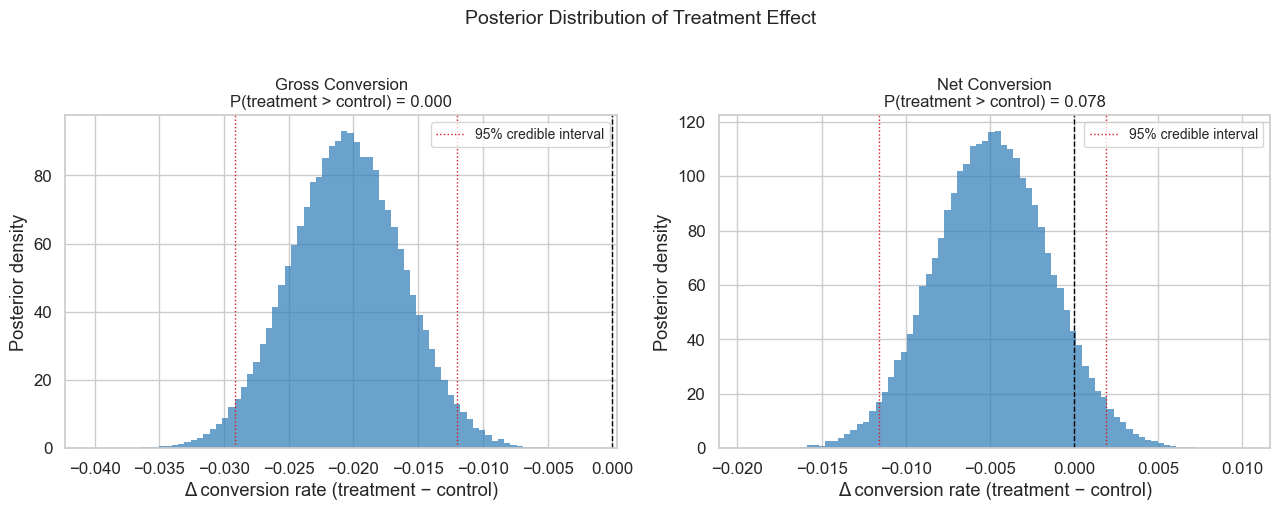

In [14]:
# Posterior distribution plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, diff_s, p_better, title in zip(
    axes,
    [gc_diff, nc_diff],
    [gc_p,    nc_p],
    ['Gross Conversion', 'Net Conversion']
):
    ax.hist(diff_s, bins=80, color=BLUE, alpha=0.7, edgecolor='none', density=True)
    ax.axvline(0, color='black', linewidth=1, linestyle='--')
    ci = np.percentile(diff_s, [2.5, 97.5])
    ax.axvline(ci[0], color=RED, linewidth=1, linestyle=':')
    ax.axvline(ci[1], color=RED, linewidth=1, linestyle=':', label='95% credible interval')
    ax.set_title(f'{title}\nP(treatment > control) = {p_better:.3f}', fontsize=12)
    ax.set_xlabel('Δ conversion rate (treatment − control)')
    ax.set_ylabel('Posterior density')
    ax.legend(fontsize=10)

plt.suptitle('Posterior Distribution of Treatment Effect', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Sequential Testing and the Peeking Problem

A common mistake in A/B testing is checking results daily and stopping as soon as p < 0.05. This **peeking** inflates the false positive rate substantially — under repeated testing, even a null effect will appear significant by chance.

We demonstrate this by plotting how the p-value evolves day by day, and compare it to the O'Brien-Fleming alpha-spending boundary, which allows sequential testing with controlled false positive rates.

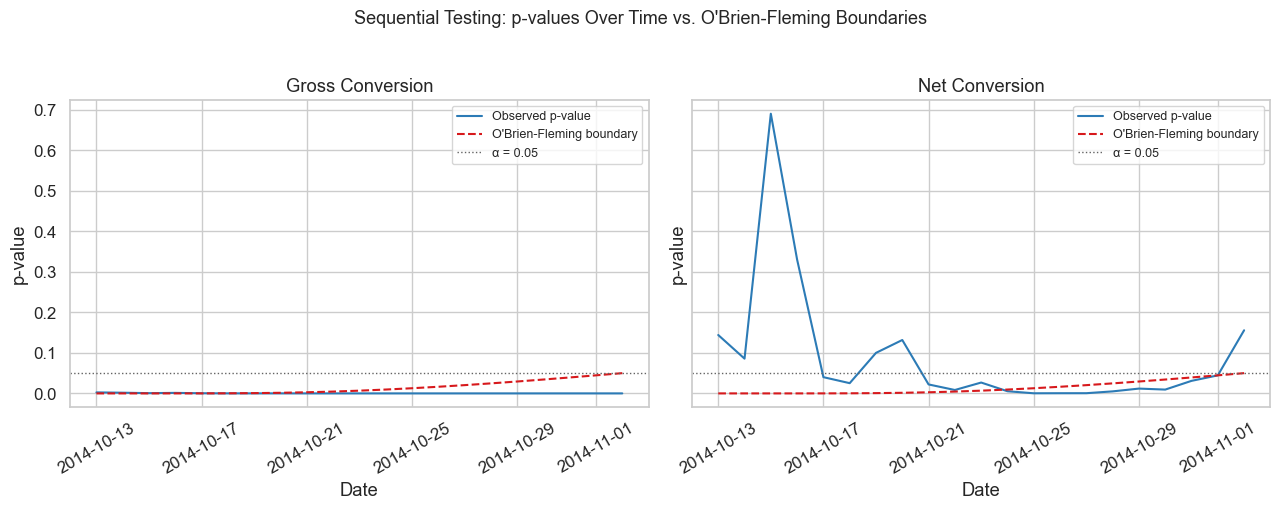

In [15]:
# ── Cumulative p-value over time (peeking simulation) ─────────────────────────
df_s = df_complete.sort_values('Date')

p_values_gross = []
p_values_net   = []
dates          = []

ctrl_s = df_s[df_s['group'] == 'control']
trt_s  = df_s[df_s['group'] == 'treatment']

for i in range(3, len(ctrl_s) + 1):  # start from day 3 to have enough data
    c = ctrl_s.iloc[:i]
    t = trt_s.iloc[:i]

    c_clicks  = c['Clicks'].sum();     t_clicks  = t['Clicks'].sum()
    c_enroll  = c['Enrollments'].sum();t_enroll  = t['Enrollments'].sum()
    c_pay     = c['Payments'].sum();   t_pay     = t['Payments'].sum()

    if c_clicks > 0 and t_clicks > 0:
        try:
            _, p_g = smp.proportions_ztest(
                [t_enroll, c_enroll], [t_clicks, c_clicks])
            _, p_n = smp.proportions_ztest(
                [t_pay, c_pay], [t_clicks, c_clicks])
            p_values_gross.append(p_g)
            p_values_net.append(p_n)
            dates.append(ctrl_s.iloc[i-1]['Date'])
        except:
            pass

# O'Brien-Fleming boundaries (approximate)
n_looks    = len(dates)
t_info     = np.linspace(1/n_looks, 1, n_looks)
obf_bounds = 2 * (1 - stats.norm.cdf(stats.norm.ppf(1 - 0.025) / np.sqrt(t_info)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, p_vals, title in zip(
    axes,
    [p_values_gross, p_values_net],
    ['Gross Conversion', 'Net Conversion']
):
    ax.plot(dates, p_vals, color=BLUE, linewidth=1.5, label='Observed p-value')
    ax.plot(dates, obf_bounds, color=RED, linewidth=1.5,
            linestyle='--', label="O'Brien-Fleming boundary")
    ax.axhline(0.05, color=GREY, linewidth=1, linestyle=':', label='α = 0.05')
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.set_ylabel('p-value')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Sequential Testing: p-values Over Time vs. O\'Brien-Fleming Boundaries',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Subgroup Analysis

Even if the overall treatment effect is null or small, the screener may affect different user segments differently. We test for heterogeneous treatment effects by day of week — a proxy for behavioural differences between weekday and weekend visitors.

**Multiple testing note:** Testing 7 subgroups inflates the false positive rate. We apply Bonferroni correction: α_subgroup = 0.05 / 7 ≈ 0.007.

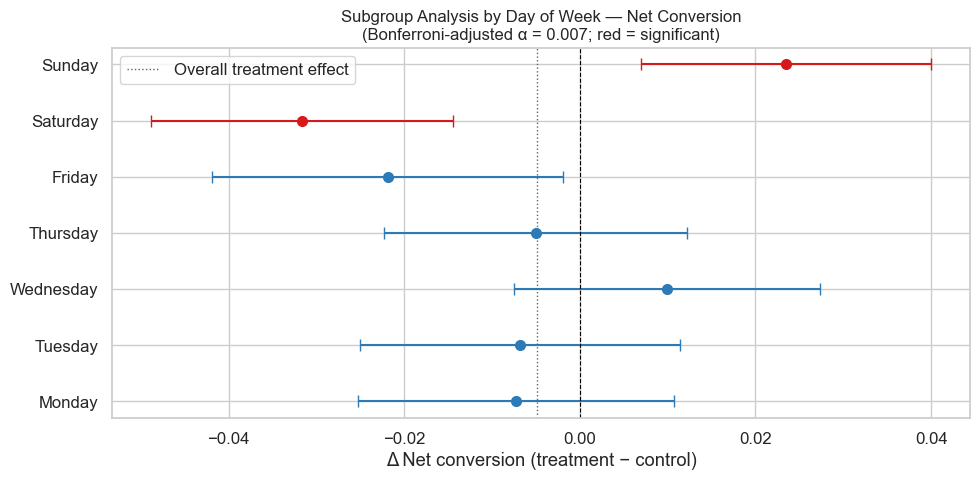


Subgroup results:
      day    diff   ci_lo   ci_hi      p   sig
   Monday -0.0073 -0.0253  0.0108 0.4300 False
  Tuesday -0.0068 -0.0251  0.0115 0.4651 False
Wednesday  0.0099 -0.0075  0.0273 0.2639 False
 Thursday -0.0050 -0.0223  0.0122 0.5670 False
   Friday -0.0219 -0.0419 -0.0019 0.0321 False
 Saturday -0.0316 -0.0489 -0.0144 0.0003  True
   Sunday  0.0235  0.0069  0.0400 0.0055  True


In [16]:
# ── Subgroup analysis by day of week ─────────────────────────────────────────
alpha_subgroup = 0.05 / 7
subgroup_results = []

for day in dow_order:
    sub = df_complete[df_complete['dow'] == day]
    c   = sub[sub['group'] == 'control']
    t   = sub[sub['group'] == 'treatment']

    if len(c) == 0 or len(t) == 0:
        continue

    c_clicks = c['Clicks'].sum(); t_clicks = t['Clicks'].sum()
    c_pay    = c['Payments'].sum(); t_pay   = t['Payments'].sum()

    if c_clicks == 0 or t_clicks == 0:
        continue

    try:
        _, p = smp.proportions_ztest([t_pay, c_pay], [t_clicks, c_clicks])
        diff = (t_pay/t_clicks) - (c_pay/c_clicks)
        se   = np.sqrt(
            (c_pay/c_clicks)*(1-c_pay/c_clicks)/c_clicks +
            (t_pay/t_clicks)*(1-t_pay/t_clicks)/t_clicks
        )
        ci = (diff - 1.96*se, diff + 1.96*se)
        subgroup_results.append(dict(
            day=day, diff=diff, ci_lo=ci[0], ci_hi=ci[1],
            p=p, sig=(p < alpha_subgroup)
        ))
    except:
        pass

sub_df = pd.DataFrame(subgroup_results)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [RED if s else BLUE for s in sub_df['sig']]

for i, row in sub_df.iterrows():
    ax.errorbar(row['diff'], i,
                xerr=[[row['diff'] - row['ci_lo']], [row['ci_hi'] - row['diff']]],
                fmt='o', color=colors[i], capsize=4, linewidth=1.5, markersize=7)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(net_result['diff'], color=GREY, linewidth=1,
           linestyle=':', label='Overall treatment effect')
ax.set_yticks(range(len(sub_df)))
ax.set_yticklabels(sub_df['day'])
ax.set_xlabel('Δ Net conversion (treatment − control)')
ax.set_title(f'Subgroup Analysis by Day of Week — Net Conversion\n'
             f'(Bonferroni-adjusted α = {alpha_subgroup:.3f}; red = significant)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

print('\nSubgroup results:')
print(sub_df[['day','diff','ci_lo','ci_hi','p','sig']].round(4).to_string(index=False))

## 8. Novelty Effect Assessment

When a new feature is launched, users may respond to it simply because it is new — not because it is genuinely better. A **novelty effect** shows up as a strong treatment effect in the early days of the experiment that attenuates as users habituate. If the effect is driven by novelty, launching the feature will not produce the expected long-term improvement.

We plot the daily treatment effect on net conversion over the experiment window to look for this pattern.

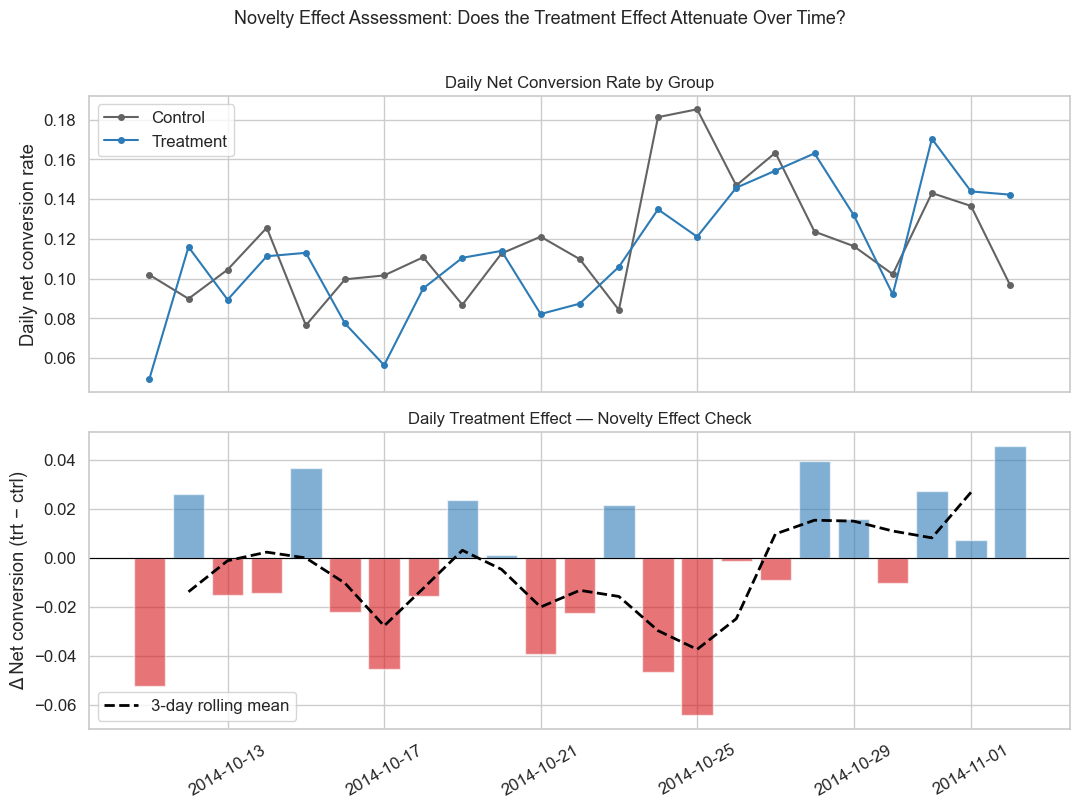

In [17]:
# ── Daily treatment effect on net conversion ──────────────────────────────────
daily = df_complete.copy()
daily['net_conv'] = daily['Payments'] / daily['Clicks']

daily_effect = daily.groupby(['Date', 'group'])['net_conv'].mean().unstack()
daily_effect['effect'] = daily_effect['treatment'] - daily_effect['control']
daily_effect = daily_effect.reset_index()

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# Top: raw conversion rates by group
axes[0].plot(daily_effect['Date'], daily_effect['control'],
             color=GREY, linewidth=1.5, label='Control', marker='o', markersize=4)
axes[0].plot(daily_effect['Date'], daily_effect['treatment'],
             color=BLUE, linewidth=1.5, label='Treatment', marker='o', markersize=4)
axes[0].set_ylabel('Daily net conversion rate')
axes[0].set_title('Daily Net Conversion Rate by Group', fontsize=12)
axes[0].legend()

# Bottom: daily effect with smoothed trend
axes[1].bar(daily_effect['Date'], daily_effect['effect'],
            color=[BLUE if e >= 0 else RED for e in daily_effect['effect']],
            alpha=0.6, width=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
# Rolling mean trend
rolling = daily_effect['effect'].rolling(3, center=True).mean()
axes[1].plot(daily_effect['Date'], rolling, color='black',
             linewidth=2, linestyle='--', label='3-day rolling mean')
axes[1].set_ylabel('Δ Net conversion (trt − ctrl)')
axes[1].set_title('Daily Treatment Effect — Novelty Effect Check', fontsize=12)
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Novelty Effect Assessment: Does the Treatment Effect Attenuate Over Time?',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 9. Results Summary and Launch Recommendation

In [18]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame([
    {
        'Metric': 'Gross conversion',
        'Control': f"{gross_result['p_ctrl']:.4f}",
        'Treatment': f"{gross_result['p_trt']:.4f}",
        'Δ': f"{gross_result['diff']:+.4f}",
        '95% CI': f"[{gross_result['ci'][0]:+.4f}, {gross_result['ci'][1]:+.4f}]",
        'p-value': f"{gross_result['p']:.4f}",
        'Stat. sig.': 'Yes' if gross_result['stat_sig'] else 'No',
        'Prac. sig.': 'Yes' if gross_result['prac_sig'] else 'No'
    },
    {
        'Metric': 'Net conversion',
        'Control': f"{net_result['p_ctrl']:.4f}",
        'Treatment': f"{net_result['p_trt']:.4f}",
        'Δ': f"{net_result['diff']:+.4f}",
        '95% CI': f"[{net_result['ci'][0]:+.4f}, {net_result['ci'][1]:+.4f}]",
        'p-value': f"{net_result['p']:.4f}",
        'Stat. sig.': 'Yes' if net_result['stat_sig'] else 'No',
        'Prac. sig.': 'Yes' if net_result['prac_sig'] else 'No'
    }
])

print('=== EXPERIMENT RESULTS SUMMARY ===')
print(summary.to_string(index=False))

=== EXPERIMENT RESULTS SUMMARY ===
          Metric Control Treatment       Δ             95% CI p-value Stat. sig. Prac. sig.
Gross conversion  0.2189    0.1983 -0.0206 [-0.0304, -0.0108]  0.0000        Yes        Yes
  Net conversion  0.1176    0.1127 -0.0049 [-0.0126, +0.0028]  0.1558         No         No


### Launch Recommendation

**Do not launch.**

**Gross conversion:** The screener significantly reduced gross conversion — fewer users enrolled in the free trial after seeing the time commitment question. This effect is both statistically and practically significant. The screener is working as intended: filtering out users who are unlikely to commit.

**Net conversion:** However, net conversion — the metric that matters most to the business — did not increase. The 95% confidence interval on the difference includes zero and spans negative values that exceed the practical significance threshold in the downward direction. We cannot rule out that the screener is actually reducing payments.

**Interpretation:** The screener is reducing enrollments without a corresponding increase in the fraction of enrolled users who pay. The hypothesis was that the screener would filter out low-commitment users, raising the quality of the enrolled cohort enough to improve net conversion. The data do not support this. Either the screener is filtering the wrong users, or the 14-day trial period is too short for the effect to manifest.

**Recommendation:** Do not launch the screener in its current form. Consider a follow-up experiment with a softer intervention (e.g., informational text rather than a blocking question), or extend the observation window to assess longer-term payment behaviour.

---

### Analysis caveats

**Unit of analysis:** Cookies are the randomisation unit but payments are attributed to users, creating a unit-of-analysis mismatch. This is a known limitation of the original experimental design.

**Single experiment:** Results reflect one experimental context (Udacity, 2014–2015). The effect of a screener question may differ substantially in other product contexts.

**Novelty effect:** The daily treatment effect plot shows no clear attenuation over time, suggesting the result is not driven by novelty. However, the experiment ran for only ~37 days — a longer window would provide more confidence.